# Regression using SciKitLearn
In this tutorial we are going to use an already clean dataset from the [Nomadlist Cities](https://nomadlist.com/) data to predict the continent where the city is located.

We are using [ScikitLearn library](https://scikit-learn.org/stable/index.html)

In [1]:
# Import standard Libraries
import pandas as pd
import seaborn as sns
import altair as alt
import matplotlib.pyplot as plt
import geopandas as gpd


sns.set(rc={'figure.figsize':(10,10)})
print("imports ok")

pd.set_option("display.float_format", "{:.3f}".format)

imports ok


In [2]:
# Load data
data = pd.read_csv('data/bcn_noise_regre_ml_dataset_with_tunnels.csv')
print(data)

                       road_id  noise_day  noise_evening  noise_night  \
0         21638891_190971702_0         65             65           60   
1          26057125_26057304_0         70             65           60   
2      3601249498_3601250399_0         65             65           60   
3         26057050_168319807_0         70             65           60   
4         26057050_178518958_0         70             65           60   
...                        ...        ...            ...          ...   
11420  8930700699_9446738721_0         55             55           50   
11421  8930700699_9446689099_0         55             55           50   
11422   559052401_3358594835_0         70             65           60   
11423   9446738720_553047568_0         55             55           50   
11424    553047566_553047568_0         55             55           50   

       road_category  dist_to_trunk  dist_to_primary  dist_to_secondary  \
0                  4        143.325         1409

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 11425 entries, 0 to 11424
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   road_id                11425 non-null  str    
 1   noise_day              11425 non-null  int64  
 2   noise_evening          11425 non-null  int64  
 3   noise_night            11425 non-null  int64  
 4   road_category          11425 non-null  int64  
 5   dist_to_trunk          11425 non-null  float64
 6   dist_to_primary        11425 non-null  float64
 7   dist_to_secondary      11425 non-null  float64
 8   dist_to_tertiary       11425 non-null  float64
 9   dist_to_residential    11425 non-null  float64
 10  dist_to_living_street  11425 non-null  float64
 11  signals                11425 non-null  float64
 12  transport              11425 non-null  float64
 13  pois                   11425 non-null  float64
 14  width                  11425 non-null  float64
 15  betweenness  

## Predicting Street-level Noise


### Select features (X)

In [4]:
# Select the (independant) features that we are going to use to train the model
X = data.drop(columns=['road_id','noise_day','noise_evening', 'noise_night'])
X

,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street,signals,transport,pois,width,betweenness,closeness_global,closeness_400,straightness,green,industrial,commercial
0,4,143.325,1409.121,146.915,0.000,151.351,184.454,0.167,0.054,0.052,50.000,0.000,0.000,0.000,0.850,0.000,0.000,0.000
1,3,1364.262,108.740,0.000,138.887,0.000,137.141,0.033,0.033,0.100,30.891,0.013,0.000,0.000,0.843,0.056,0.000,0.000
2,6,3061.643,399.681,0.000,406.820,62.360,0.000,0.019,0.019,0.115,3.771,0.001,0.000,0.000,0.823,2.767,0.000,0.000
3,2,1146.110,0.000,40.129,0.000,102.119,130.263,0.122,0.054,0.000,50.000,0.006,0.000,0.000,0.853,0.000,0.000,0.000
4,2,1039.407,0.000,81.608,10.012,0.000,130.263,0.078,0.052,0.009,41.989,0.005,0.000,0.000,0.850,0.000,0.000,5.936
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11420,5,1166.465,3718.930,504.637,2.622,0.000,857.337,0.000,0.000,0.000,50.000,0.000,0.000,0.000,0.809,15.246,100.000,0.000
11421,5,1164.506,3718.930,504.637,5.402,0.000,857.337,0.000,0.000,0.000,50.000,0.000,0.000,0.000,0.808,15.278,100.000,0.000
11422,4,2094.224,1392.526,0.000,0.000,22.953,40.225,0.070,0.009,0.009,34.152,0.002,0.000,0.000,0.847,3.313,0.000,0.000
11423,5,1185.946,3731.357,511.507,0.000,0.000,852.508,0.000,0.000,0.000,50.000,0.001,0.000,0.000,0.812,16.276,100.000,0.000


### Standard scaling

In [5]:
# Load and instantiate a StandardSclaer
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

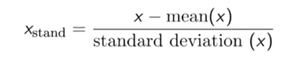

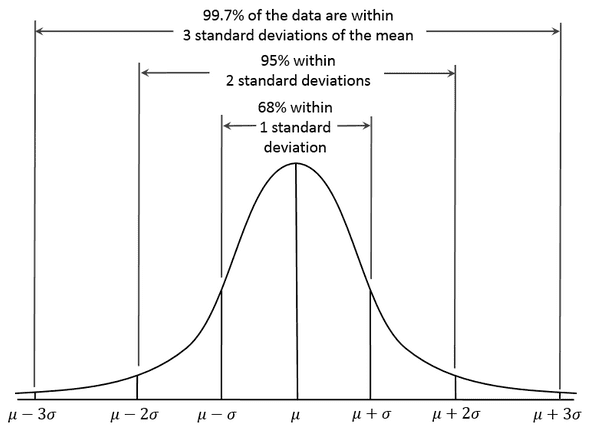

In [6]:
# Apply the scaler to our X-features
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-0.61235772, -1.20158202,  0.88649058, ..., -0.49072815,
        -0.19937592, -0.14211017],
       [-1.59621188,  0.30939294, -0.79463258, ..., -0.48753928,
        -0.19937592, -0.14211017],
       [ 1.3553506 ,  2.40999531, -0.41850682, ..., -0.33185749,
        -0.19937592, -0.14211017],
       ...,
       [-0.61235772,  1.21276089,  0.86503644, ..., -0.30048685,
        -0.19937592, -0.14211017],
       [ 0.37149644,  0.08871749,  3.88865898, ...,  0.44387108,
         6.21753778, -0.14211017],
       [-0.61235772,  0.08871749,  3.88865898, ...,  0.49926928,
         6.21753778, -0.14211017]], shape=(11425, 18))

In [7]:
print(X_scaled.shape)
tdf = pd.DataFrame(X_scaled)

#print(type(X_scaled))
print(tdf.describe())

(11425, 18)
             0         1         2         3         4         5         6   \
count 11425.000 11425.000 11425.000 11425.000 11425.000 11425.000 11425.000   
mean      0.000     0.000     0.000    -0.000    -0.000     0.000    -0.000   
std       1.000     1.000     1.000     1.000     1.000     1.000     1.000   
min      -3.564    -1.379    -0.935    -0.900    -0.855    -0.320    -0.537   
25%      -0.612    -0.885    -0.698    -0.750    -0.855    -0.320    -0.537   
50%       0.371    -0.144    -0.293    -0.288    -0.252    -0.320    -0.272   
75%       0.371     0.776     0.369     0.400     0.460    -0.320     0.088   
max       1.355     2.452     5.102     5.571     5.896    18.593     8.541   

             7         8         9         10        11        12        13  \
count 11425.000 11425.000 11425.000 11425.000 11425.000 11425.000 11425.000   
mean     -0.000     0.000     0.000    -0.000    -0.000    -0.000     0.000   
std       1.000     1.000     1.000    

### Define dependant variable (Y)

In [8]:
# Define the dependant variable / target to predict
y_reg = data.noise_day
print(y_reg)

0        65
1        70
2        65
3        70
4        70
         ..
11420    55
11421    55
11422    70
11423    55
11424    55
Name: noise_day, Length: 11425, dtype: int64


### Split data

In [9]:
#Split the data using the train_test_split module. We keep 20% of the data for testing and use 80% to train the model
# Random state defined with an arbitrary number for reproducibility

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test, data_train, data_test = train_test_split(X_scaled, y_reg, data, test_size = 0.2, random_state = 42)

In [10]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(9140, 18)
(9140,)
(2285, 18)
(2285,)


## Linear Regression

### Train model

In [11]:
# Import and instantiate the baseline model
from sklearn.linear_model import LinearRegression
model = LinearRegression()

# Model training
model.fit(X_train, y_train)

# Model performance on the test-set / This score is R^2
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

score_linear = model.score(X_test, y_test)

0.4465250806388019
0.4409051058738962


In [12]:
print("Coefficient", model.coef_, "intercetp",  model.intercept_)

Coefficient [-1.56573645  0.09414722 -0.94035571 -0.4262606  -0.80737508  0.30765615
  0.75168901  1.00691417  0.56413993  0.18704693  0.22613312  0.35371787
  1.34729222 -0.25193544  1.48131512 -0.43619651  0.45794056 -0.00863015] intercetp 59.57671175008882


### Inspect results

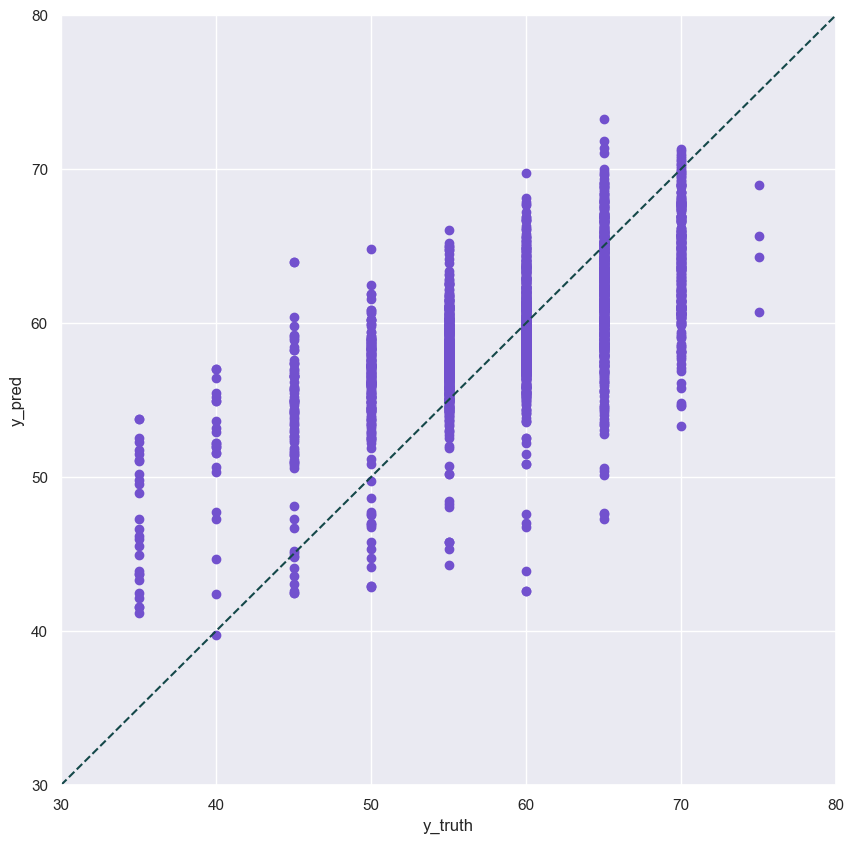

In [13]:
# We can also inspect our results visually
y_pred = model.predict(X_test)
data_test['diff_xg'] = y_test - y_pred

plt.scatter(y_test,y_pred, color = '#7251ceff')

plt.xlabel("y_truth")
plt.ylabel("y_pred")
plt.xlim(30, 80)
plt.ylim(30, 80)
plt.axline((0,0), slope = 1, ls="--", color = "#144849ff")

In [14]:
data_test.info()

<class 'pandas.DataFrame'>
Index: 2285 entries, 304 to 36
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   road_id                2285 non-null   str    
 1   noise_day              2285 non-null   int64  
 2   noise_evening          2285 non-null   int64  
 3   noise_night            2285 non-null   int64  
 4   road_category          2285 non-null   int64  
 5   dist_to_trunk          2285 non-null   float64
 6   dist_to_primary        2285 non-null   float64
 7   dist_to_secondary      2285 non-null   float64
 8   dist_to_tertiary       2285 non-null   float64
 9   dist_to_residential    2285 non-null   float64
 10  dist_to_living_street  2285 non-null   float64
 11  signals                2285 non-null   float64
 12  transport              2285 non-null   float64
 13  pois                   2285 non-null   float64
 14  width                  2285 non-null   float64
 15  betweenness         

In [15]:
data_test['noisePred_reg'] = y_pred

alt.Chart(data_test).mark_circle(size=60).encode(
    x='noise_day',
    y='noisePred_reg',
    color=alt.Color('road_category', scale=alt.Scale(scheme='category10')),
    tooltip=['road_id']
).interactive()

alt.Chart(...)

## XGBoost

### Train with new model

In [16]:
# Import and instantiate a XGBoost Regressor
import xgboost as xgb
model = xgb.XGBRegressor()

# Model training
model.fit(X_train, y_train)

# Model performance on the test-set / This score is not accacy but a R^2
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))
score_xgb = model.score(X_test, y_test)

0.911127507686615
0.6622824668884277


### Inspect results

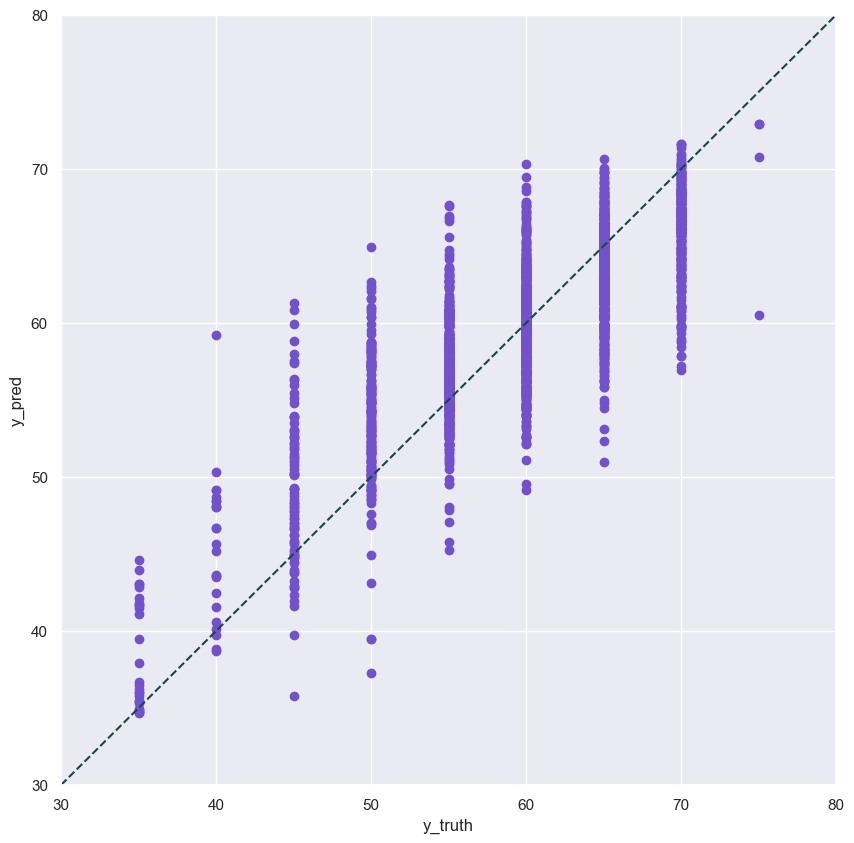

In [17]:
# We can also inspect our results visually
y_pred = model.predict(X_test)

plt.scatter(y_test,y_pred, color = '#7251ceff')

plt.xlabel("y_truth")
plt.ylabel("y_pred")
plt.xlim(30, 80)
plt.ylim(30, 80)
plt.axline((0,0), slope = 1, ls="--", color = "#144849ff")

In [18]:
data_test['noisePred_xg'] = y_pred

alt.Chart(data_test).mark_circle(size=60).encode(
    x='noise_day',
    y='noisePred_xg',
    color=alt.Color('road_category', scale=alt.Scale(scheme='category10')),
    tooltip=['road_id']
).interactive()

alt.Chart(...)

## Compare results

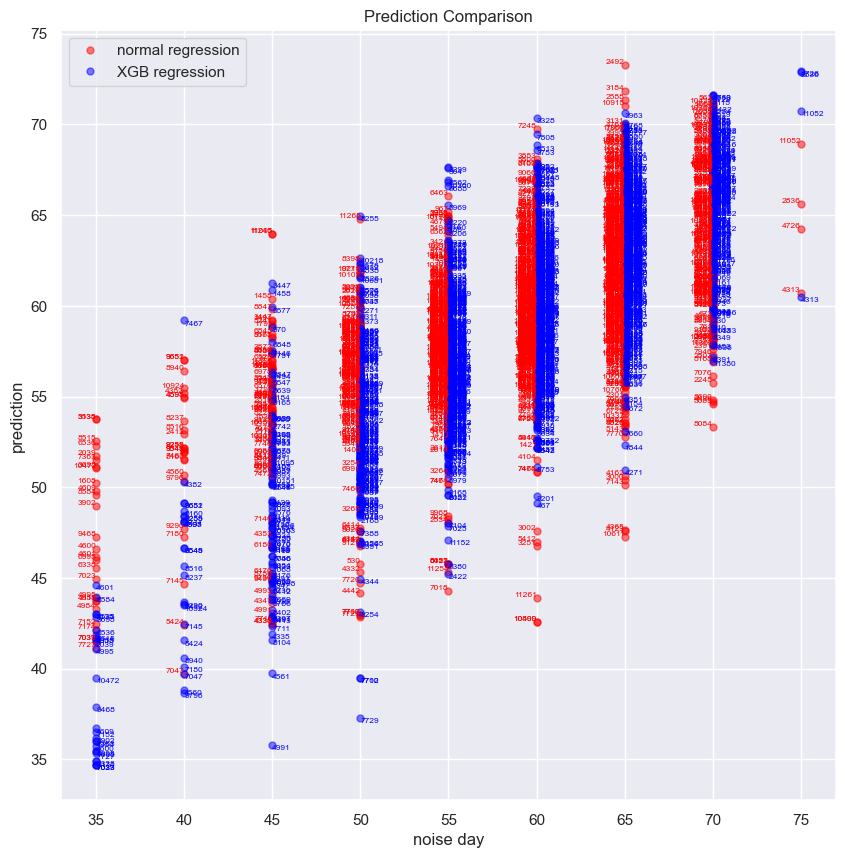

In [19]:
# Comparative plot
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 10))

ax1.plot(
    data_test["noise_day"],
    data_test["noisePred_reg"],
    color="red",
    label="normal regression",
    linestyle='None',
    marker="o",
    markersize=5,
    alpha = 0.5
)

ax1.plot(
    data_test["noise_day"],
    data_test["noisePred_xg"],
    color="blue",
    label="XGB regression",
    linestyle='None',
    marker="o",
    markersize=5,
    alpha=0.5
)

# Labels for red points (normal regression)
for idx, (x, y) in data_test[["noise_day", "noisePred_reg"]].iterrows():
    ax1.text(x, y, str(idx), fontsize=6, ha='right', va='bottom', color="red")

# Labels for blue points (XGB regression)
for idx, (x, y) in data_test[["noise_day", "noisePred_xg"]].iterrows():
    ax1.text(x, y, str(idx), fontsize=6, ha='left', va='top', color="blue")

ax1.set_xlabel('noise day')
ax1.set_ylabel('prediction')
ax1.legend()

plt.title('Prediction Comparison')
plt.show()

## Random Forest

In [20]:

from sklearn.ensemble import RandomForestRegressor


model = RandomForestRegressor(
    random_state=42,
    max_depth=None,         
    min_samples_leaf=1,    
    min_samples_split=2,   
)

# Model training
model.fit(X_train, y_train)

# Model performance on the test-set / This score is not accacy but a R^2
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

0.9555153406804282
0.6838275379399307


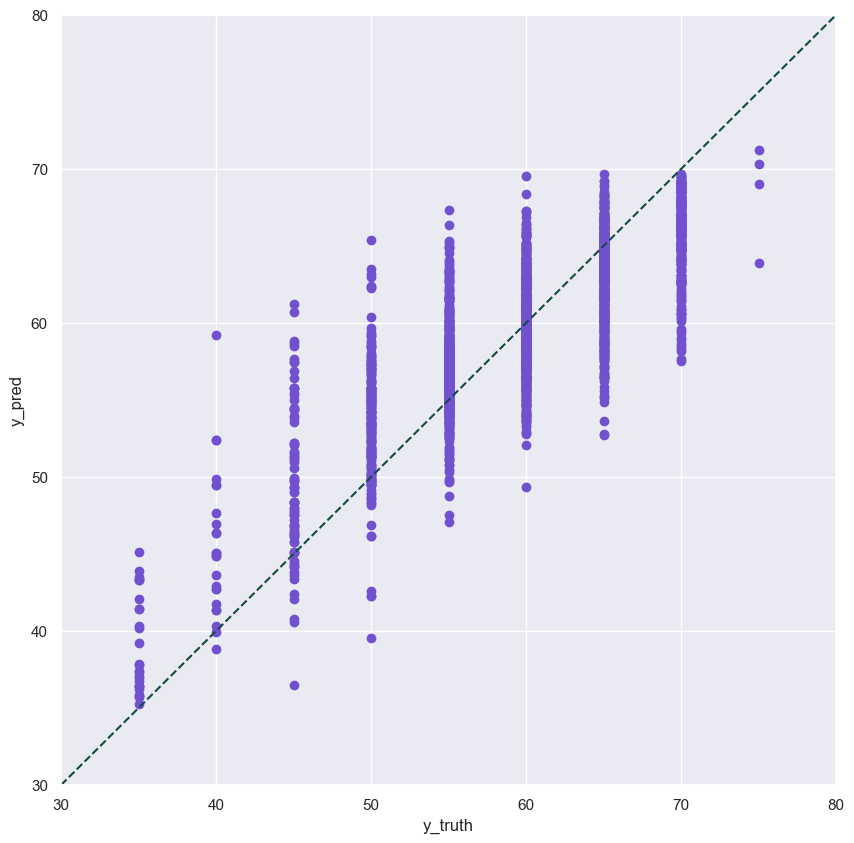

In [21]:
# We can also inspect our results visually
y_pred = model.predict(X_test)
plt.scatter(y_test,y_pred, color = '#7251ceff')
plt.xlabel("y_truth")
plt.ylabel("y_pred")
plt.xlim(30, 80)
plt.ylim(30, 80)
plt.axline((0,0), slope = 1, ls="--", color = "#144849ff")

### Inspect results

In [22]:
data_test["y_pred"]= y_pred
data_test["y_truth"]= y_test
data_test["y_diff"]= y_pred - y_test

In [23]:
data_test['noisePred_xg'] = y_pred
alt.Chart(data_test).mark_circle(size=60).encode(
    x='noise_day',
    y='noisePred_xg',
    color=alt.Color('road_category', scale=alt.Scale(scheme='category10')),
    tooltip=['road_id']
).interactive()

alt.Chart(...)

### See results in interactive map

In [24]:
osm_roads = gpd.read_file("data/bcn_osmnx_edges.gpkg")
merged_gdf = osm_roads.merge(data_test, left_on='segment_id', right_on='road_id', how='left')

In [25]:
m = merged_gdf.to_crs(epsg=4326).explore(
    column='y_diff',
    cmap='RdBu',
    tiles='CartoDB positron',
    tooltip=['road_id', 'y_diff', 'y_pred', 'y_truth', 'highway'],
    legend=True,
)
m.save("map_y_diff.html")

import webbrowser, os
webbrowser.open('file://' + os.path.realpath("map_y_diff.html"))

True